In [17]:
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from operator import add

In [18]:
load_dotenv()

True

In [19]:
llm = ChatAnthropic(model="claude-haiku-4-5-20251001")

In [20]:
class State(TypedDict):
    age:int
    remark:str

In [21]:
graph = StateGraph(State)

In [22]:
def router(state:State):
    if state['age'] > 17:
        return 'adult'
    else:
        return 'young'

In [23]:
def adult(state:State):
    return {'remark':"able to vote"}

In [24]:
def young(state:State):
    return {'remark':"too young not able to vote"}

In [25]:
def check_node(state:State):
    return {}

In [26]:
graph.add_node('check_node', check_node)
graph.add_node('adult', adult)
graph.add_node('young', young)

In [27]:
graph.add_edge(START, 'check_node')
graph.add_conditional_edges("check_node", router)
graph.add_edge('adult', END)
graph.add_edge('young', END)

In [28]:
workflow = graph.compile()

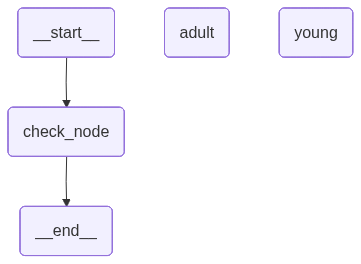

In [29]:
workflow